## Notebook 7: AC Electricity Consumption, Downscaling

In [1]:
import os
os.environ["CITY"] = "rome"   # pick the city here

In [2]:
# Generic bootstrap 
from pathlib import Path
import os, sys

def _find_root():
    start = Path.cwd()
    for cand in [start, *start.parents]:
        if (cand/"cityheat").is_dir() and (cand/"configs").is_dir():
            return cand
    raise RuntimeError("Repo root not found.")
ROOT = _find_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from cityheat.nbsetup import bootstrap
from cityheat.paths import make_P, ensure_out

# Choose city here
SLUG = globals().get("SLUG", os.environ.get("CITY", "rome")).lower()

C    = bootstrap(SLUG)      # reads configs/<slug>.yml and syncs that city only if wanted
CFG  = C["CFG"]; CITY = C["CITY"]
BASE = C["BASE"]; OUT = C["OUT"]; INT = C["INT"]

P    = make_P(BASE)         # read-only path helper
OUTP = ensure_out(OUT)      # write-safe path helper
print(f"→ City: {CITY}  |  BASE={BASE}  OUT={OUT}  INT={INT}")

→ City: rome  |  BASE=/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/rome  OUT=/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome  INT=/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome/interim


In [3]:
# city config + file paths from YAML 
cfg = C.get("cfg", {})                      # full YAML for the selected city
SLUG = cfg.get("slug", SLUG).lower()        
CITY = cfg.get("city_name", CITY)

paths    = cfg.get("files", {})             # {gvi_csv, lcz_candidates, cooling_coeffs_csv, ...}
osm_cfg  = cfg.get("osm", {})               # OSM settings used later in NB5
trees_cfg = cfg.get("trees", {})            # TARGET/CAP for NB5
urbclim   = cfg.get("urbclim", {})          # UrbClim folder/settings for NB5

lcz_candidates = [P(p) for p in paths.get("lcz_candidates", [])]
gvi_path = P(paths.get("gvi_csv", ""))

# FUA geopackage written in NB2 
fua_gpkg = Path(paths.get("fua_gpkg", f"{OUT}/{SLUG}_fua.gpkg"))

cool_csv = P(paths.get("cooling_coeffs_csv", ""))

# checks
print("SLUG/CITY:", SLUG, CITY)
print("GVI CSV:  ", gvi_path)
print("LCZ cand: ", [str(p) for p in lcz_candidates])
print("FUA GPKG: ", fua_gpkg)
print("Cooling CSV:", cool_csv)

SLUG/CITY: rome Rome
GVI CSV:   /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/rome/gviRome/gvi_Rome.csv
LCZ cand:  ['/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/rome/LCZ/lcz_filter_v3.tif', '/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/rome/LCZ/lcz_v3.tif']
FUA GPKG:  /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome/rome_fua.gpkg
Cooling CSV: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/rome/CoolingEff/outer_2_wbgt_max.csv


**Loading from before**

In [4]:
# helper: picking first existing path from candidates 
def _first_existing(*cands, glob_pattern=None):
    for p in cands:
        p = Path(p)
        if p.exists():
            return p
    if glob_pattern is not None:
        hits = sorted(Path(OUT).glob(glob_pattern))
        if len(hits) == 1:
            return hits[0]
    return None

In [5]:
import numpy as np
import rasterio as rio
import geopandas as gpd
import pandas as pd
from pathlib import Path

# FUA / Regions paths 
fua_gpkg = Path(paths.get("fua_gpkg", OUT / f"{SLUG}_fua.gpkg"))
fua_gpkg = _first_existing(fua_gpkg, OUT / "fua.gpkg", glob_pattern="*_fua.gpkg")
assert fua_gpkg and fua_gpkg.exists(), "Missing FUA geopackage."

regions_gpkg = Path(paths.get("regions_gpkg", OUT / f"{SLUG}_regions.gpkg"))
regions_gpkg = _first_existing(regions_gpkg, OUT / "regions.gpkg", glob_pattern="*_regions.gpkg")
assert regions_gpkg and regions_gpkg.exists(), "Missing regions geopackage."

muni_on_ref_tif = Path(paths.get("muni_on_ref_tif", OUT / f"{SLUG}_muni_on_ref.tif"))
muni_on_ref_tif = _first_existing(muni_on_ref_tif, OUT / "muni_on_ref.tif", glob_pattern="*_muni_on_ref.tif")
assert muni_on_ref_tif and muni_on_ref_tif.exists(), "Missing muni_on_ref.tif (save it in NB5)."

# LUTs 
muni_lut_csv = Path(paths.get("muni_lut_csv", OUT / f"{SLUG}_muni_lut.csv"))
muni_lut_csv = _first_existing(muni_lut_csv, OUT / "muni_lut.csv", glob_pattern="*_muni_lut.csv")
assert muni_lut_csv and muni_lut_csv.exists(), "Missing muni_lut.csv (save it in NB5)."
lut = (pd.read_csv(muni_lut_csv)
         .assign(muni_id=lambda d: d["muni_id"].astype(int))
         .sort_values("muni_id"))
print("Using muni LUT:", muni_lut_csv.name, "| rows:", len(lut))

cap_gpkg = Path(paths.get("cap_gpkg", OUT / f"{SLUG}_cap.gpkg"))
cap_gpkg = _first_existing(cap_gpkg, OUT / "cap.gpkg", glob_pattern="*_cap.gpkg")
assert cap_gpkg and cap_gpkg.exists(), "Missing CAP geopackage."

cap_lut_csv = Path(paths.get("cap_lut_csv", OUT / f"{SLUG}_cap_lut.csv"))
cap_lut_csv = _first_existing(cap_lut_csv, OUT / "cap_lut.csv", glob_pattern="*_cap_lut.csv")
assert cap_lut_csv and cap_lut_csv.exists(), "Missing cap_lut.csv (save it in NB6)."
cap_ref_lut = (pd.read_csv(cap_lut_csv).astype({"cap_id": int, "cap5": str}).drop_duplicates())
print("Using CAP LUT:", cap_lut_csv.name, "| rows:", len(cap_ref_lut))

cap_wgs84_lut_path = Path(paths.get("cap_wgs84_lut", OUT / f"{SLUG}_cap_wgs84_lut.csv"))
cap_wgs84_lut_path = _first_existing(cap_wgs84_lut_path, OUT / "cap_wgs84_lut.csv", glob_pattern="*_cap_wgs84_lut.csv")
cap_wgs84_lut_df = None
if cap_wgs84_lut_path and cap_wgs84_lut_path.exists():
    cap_wgs84_lut_df = (pd.read_csv(cap_wgs84_lut_path).astype({"cap_id": int, "cap5": str}).drop_duplicates())
    print("Using CAP WGS84 LUT:", cap_wgs84_lut_path.name)

# Reference grid + city mask
tmpl_path = INT / "template_ref.tif"   # T2M ref grid
mask_tif  = INT / "city_mask.tif"      # boolean mask on that grid
with rio.open(tmpl_path) as src:
    ref_meta = src.meta.copy()
    HGT, WDT = ref_meta["height"], ref_meta["width"]
with rio.open(mask_tif) as src:
    CITY_MASK = src.read(1).astype(bool)

ref_data = np.where(CITY_MASK, 0.0, np.nan)
HAZ_MASK = np.isfinite(ref_data)

# Hot-days stack
# T2M hazard stack on ref grid (mean daily T2M per year)
t2m_npz_path = _first_existing(
    INT / f"t2m_hazard_2030_2100_{SLUG}.npz",
    INT / "t2m_hazard_2030_2100.npz",
    glob_pattern="t2m_hazard_2030_2100*.npz"
)
assert t2m_npz_path and t2m_npz_path.exists(), "Missing T2M hazard .npz (run NB3)."

npz   = np.load(t2m_npz_path)
YEARS = npz["years"].astype(int)        # (n_years,)
DATA  = npz["data"].astype("float32")   # (n_years, HGT, WDT)
assert DATA.shape[1:] == (HGT, WDT), f"T2M hazard grid {DATA.shape[1:]} != ref grid {(HGT, WDT)}"

H2050 = DATA[list(YEARS).index(2050)]
print("Loaded T2M hazard:", t2m_npz_path.name, "| years:", YEARS.min(), "→", YEARS.max())

# AC coverage 
# AC coverage: allow 2D (single map) or 3D (yearly maps), pick same year as hazard (2050)

cov_path = _first_existing(
    INT / f"ac_coverage_maps_{SLUG}.npz",
    INT / "ac_coverage_maps.npz",
    glob_pattern="ac_coverage_maps*.npz",
)
assert cov_path and cov_path.exists(), f"Missing AC coverage NPZ at {cov_path}"

d = np.load(cov_path)
coverage_base_raw   = d["coverage_base"].astype("float32")
coverage_policy_raw = d["coverage_policy"].astype("float32")
years_cov = d["years"].astype(int) if "years" in d.files else None

# Choose the year consistent with the hazard we use below (H2050)
year_target = 2050

def _pick_cov_for_year(arr, year_target, years_cov=None, fallback_years=None):
    """
    Return a 2D AC coverage grid for a specific year.

    - If arr is 2D: assume it's the same for all years → just return it.
    - If arr is 3D: arr.shape = (nyears, H, W) and we match along years_cov or fallback_years.
    """
    if arr.ndim == 2:
        return arr
    if arr.ndim == 3:
        if years_cov is not None:
            ys = [int(y) for y in years_cov]
        elif fallback_years is not None:
            ys = [int(y) for y in fallback_years]
        else:
            raise ValueError("3D coverage array but no years metadata provided.")
        assert arr.shape[0] == len(ys), "coverage_base 0-axis must match number of years"
        if year_target not in ys:
            raise KeyError(f"Year {year_target} not found in coverage years: {ys}")
        i = ys.index(int(year_target))
        return arr[i, :, :]
    raise ValueError(f"Unexpected coverage array dim {arr.ndim}")

# Use hazard YEARS as fallback if needed (already loaded above from T2M NPZ)
coverage_base   = _pick_cov_for_year(coverage_base_raw,   year_target, years_cov, YEARS)
coverage_policy = _pick_cov_for_year(coverage_policy_raw, year_target, years_cov, YEARS)

# Optional: CAP_MASK from NPZ if present, else derive from CAP raster
if "CAP_MASK" in d.files:
    CAP_MASK = d["CAP_MASK"].astype(bool)
else:
    CAP_MASK = (CITY_MASK & (cap_on_ref > 0))

assert coverage_base.shape == (HGT, WDT)
assert coverage_policy.shape == (HGT, WDT)

# Population / CAP rasters 
def _load_pop_on_ref(INT, SLUG, HGT, WDT):
    pop_npz_path = _first_existing(
        INT / f"pop_on_ref_{SLUG}.npz",
        INT / "pop_on_ref.npz",
        glob_pattern="pop_on_ref*.npz"
    )
    if pop_npz_path and pop_npz_path.exists():
        pop = np.load(pop_npz_path)["pop"].astype("float32")
    else:
        # fallback to GeoTIFF saved in NB5
        with rio.open(INT / "pop_on_ref.tif") as src:
            pop = src.read(1).astype("float32")
            assert (src.height, src.width) == (HGT, WDT), "pop_on_ref.tif grid mismatch."
    assert pop.shape == (HGT, WDT), f"pop_on_ref shape {pop.shape} != {(HGT, WDT)}"
    return pop

def _load_age_on_ref(INT, SLUG, HGT, WDT):
    age_npz_path = _first_existing(
        INT / f"age_on_ref_{SLUG}.npz",
        INT / "age_on_ref.npz",
        glob_pattern="age_on_ref*.npz"
    )
    if age_npz_path and age_npz_path.exists():
        d = np.load(age_npz_path)
        age = {"<15": d["lt15"].astype("float32"),
               "15-64": d["a15_64"].astype("float32"),
               "65+": d["g65"].astype("float32")}
    else:
        # fallback to per-band GeoTIFFs saved in NB5
        age = {}
        with rio.open(INT / "age_lt15_on_ref.tif") as s:  age["<15"]  = s.read(1).astype("float32")
        with rio.open(INT / "age_15_64_on_ref.tif") as s: age["15-64"] = s.read(1).astype("float32")
        with rio.open(INT / "age_65p_on_ref.tif") as s:   age["65+"]  = s.read(1).astype("float32")
    for k,v in age.items():
        assert v.shape == (HGT, WDT), f"age {k} shape {v.shape} != {(HGT, WDT)}"
    return age

# using them
pop_on_ref = _load_pop_on_ref(INT, SLUG, HGT, WDT)
age_on_ref = _load_age_on_ref(INT, SLUG, HGT, WDT)

print("Loaded exposure:",
      f"\n  pop_on_ref: {pop_on_ref.shape}, sum={np.nansum(pop_on_ref):.0f}",
      f"\n  age lt15:   {age_on_ref['<15'].shape}, sum={np.nansum(age_on_ref['<15']):.0f}",
      f"\n  age 15-64:  {age_on_ref['15-64'].shape}, sum={np.nansum(age_on_ref['15-64']):.0f}",
      f"\n  age 65+:    {age_on_ref['65+'].shape}, sum={np.nansum(age_on_ref['65+']):.0f}",
)

# CAP raster on ref grid
def _load_cap_on_ref(INT, SLUG, HGT, WDT):
    cap_npz_path = _first_existing(
        INT / f"cap_on_ref_{SLUG}.npz",
        INT / "cap_on_ref.npz",
        glob_pattern="cap_on_ref*.npz"
    )
    if cap_npz_path and cap_npz_path.exists():
        cap = np.load(cap_npz_path)["cap_on_ref"].astype("int32")
    else:
        # fallback to GeoTIFF written in NB6
        with rio.open(INT / f"cap_on_ref_{SLUG}.tif") as src:
            cap = src.read(1).astype("int32")
            assert (src.height, src.width) == (HGT, WDT), "cap_on_ref.tif grid mismatch."
    assert cap.shape == (HGT, WDT), f"cap_on_ref shape {cap.shape} != {(HGT, WDT)}"
    return cap

cap_on_ref = _load_cap_on_ref(INT, SLUG, HGT, WDT)

# Vectors 
fua = gpd.read_file(fua_gpkg).to_crs("EPSG:4326")
regions = gpd.read_file(regions_gpkg, layer="regions").set_crs("EPSG:4326")
muni    = gpd.read_file(regions_gpkg, layer="muni").set_crs("EPSG:4326")

with rio.open(muni_on_ref_tif) as src:
    muni_on_ref = src.read(1).astype("int32")
    assert (src.crs == ref_meta["crs"]) and (src.transform == ref_meta["transform"]), "Grid mismatch."

print("Loaded regions:", len(regions), "polygons; muni_on_ref shape:", muni_on_ref.shape)
print("Unique muni IDs on grid (>=0):", int(np.unique(muni_on_ref[muni_on_ref >= 0]).size))

cap_ref  = gpd.read_file(cap_gpkg, layer="cap").to_crs(ref_meta["crs"])
cap_4326 = gpd.read_file(cap_gpkg, layer="cap_wgs84").to_crs("EPSG:4326")

print("Loaded:",
      "\n  FUA:", fua_gpkg.name,
      "\n  Regions:", regions_gpkg.name,
      "\n  muni_on_ref:", muni_on_ref_tif.name, muni_on_ref.shape,
      "\n  CAPs:", cap_gpkg.name)

Using muni LUT: rome_muni_lut.csv | rows: 16
Using CAP LUT: rome_cap_lut.csv | rows: 118
Using CAP WGS84 LUT: rome_cap_wgs84_lut.csv
Loaded T2M hazard: t2m_hazard_2030_2100_rome.npz | years: 2030 → 2050
Loaded exposure: 
  pop_on_ref: (301, 301), sum=2548154 
  age lt15:   (301, 301), sum=277144 
  age 15-64:  (301, 301), sum=1580341 
  age 65+:    (301, 301), sum=690669
Loaded regions: 16 polygons; muni_on_ref shape: (301, 301)
Unique muni IDs on grid (>=0): 16
Loaded: 
  FUA: rome_fua.gpkg 
  Regions: rome_regions.gpkg 
  muni_on_ref: rome_muni_on_ref.tif (301, 301) 
  CAPs: rome_cap.gpkg


<blockquote style="border-left:4px solid #ccc; padding-left:1em;">
Parametrisation of the AC costs: using the gridded AC data : divide TWh layers by pop layers, convert units to get average AC electricity use (kWh / capita + year)
</blockquote>

**Loading the data**

In [7]:
# AC NetCDF selection: AC electricity consumption for SSP2 

import xarray as xr, numpy as np, re
from shapely.geometry import box
from pyproj import CRS
from shapely.ops import transform as shp_transform

# choosing only ssp, because then different years
ssp_choice = 2

nc_path = P(cfg.get("ac", {}).get("gridded_file", "ACgridded/ac_kWh_ssp1_ssp2_ssp3_ssp5_2010_2050.nc"))
assert nc_path.exists(), f"Missing {nc_path} — run Notebook 1 (Drive sync)."
ds = xr.open_dataset(nc_path, decode_times=False)

def pick_one(seq, options):
    for name in options:
        if name in seq: 
            return name
    low = {s.lower(): s for s in seq}
    for name in options:
        if name.lower() in low: 
            return low[name.lower()]
    return None

DIM_LAT  = pick_one(ds.dims, ["latitude", "lat", "y"])
DIM_LON  = pick_one(ds.dims, ["longitude", "lon", "x"])
DIM_SSP  = pick_one(ds.dims, ["SSP", "ssp", "scenario"])
DIM_TIME = pick_one(ds.dims, ["Time", "time", "year"])

def pick_var(ds):
    for v in ds.data_vars:
        hay = f"{v.lower()} " + " ".join(f"{k} {str(ds[v].attrs[k]).lower()}" 
                                         for k in ds[v].attrs)
        if ("ac" in hay) and ("electric" in hay or "kwh" in hay):
            return v
    return list(ds.data_vars)[0]

VAR = pick_var(ds)

def decode_years(vals, units):
    vals = np.asarray(vals, dtype=float)
    if np.all((vals >= 1800) & (vals <= 2600)):
        return vals.astype(int)
    units = (units or "").lower()
    m = re.search(r"years\s+since\s+(\d{4})", units)
    return (int(m.group(1)) + vals).astype(int) if m else vals.astype(int)

yrs = decode_years(ds[DIM_TIME].values, ds[DIM_TIME].attrs.get("units", ""))
ds  = ds.assign_coords({DIM_TIME: yrs})

def select_label(vals, desired):
    vals_np = np.asarray(vals)
    if np.issubdtype(vals_np.dtype, np.number):
        return vals_np[int(np.argmin(np.abs(vals_np - float(desired))))]
    want = str(desired)
    for cand in [want, f"SSP{int(desired)}", f"ssp{int(desired)}", f"{int(desired)}"]:
        m = [v for v in vals if str(v).lower() == cand.lower()]
        if m: 
            return m[0]
    return list(vals)[0]

ssp_label = select_label(ds[DIM_SSP].values, ssp_choice)

# mask fill values
da = ds[VAR]
for mv in [da.attrs.get("_FillValue"),
           da.encoding.get("_FillValue"),
           da.attrs.get("missing_value"),
           -999.0, -9999.0]:
    if mv is not None:
        da = da.where(da != mv)

# choosing "city pixel" by centroid 

# FUA geometry in WGS84 (already loaded above as `fua`)
gseries = fua.to_crs("EPSG:4326").geometry
fua_ll = gseries.union_all() if hasattr(gseries, "union_all") else gseries.unary_union

lats = ds[DIM_LAT].values
lons = ds[DIM_LON].values

# centroid of city polygon in lat/lon
cy, cx = fua_ll.centroid.y, fua_ll.centroid.x   # lat, lon

# nearest grid indices
i0 = int(np.argmin(np.abs(lats - cy)))
j0 = int(np.argmin(np.abs(lons - cx)))

# helper to move to nearest finite cell if needed
def nearest_finite_cell(sl, i0, j0, max_radius=3):
    if np.isfinite(sl[i0, j0]):
        return i0, j0
    H, W = sl.shape
    best = None
    best_d2 = None
    for r in range(1, max_radius + 1):
        for di in range(-r, r+1):
            for dj in range(-r, r+1):
                ii, jj = i0 + di, j0 + dj
                if (ii < 0) or (ii >= H) or (jj < 0) or (jj >= W):
                    continue
                if not np.isfinite(sl[ii, jj]):
                    continue
                d2 = di*di + dj*dj
                if best is None or d2 < best_d2:
                    best = (ii, jj)
                    best_d2 = d2
        if best is not None:
            break
    return best

# using 2050 to pick a reference cell
sl_2050 = da.sel({DIM_SSP: ssp_label, DIM_TIME: 2050}).transpose(DIM_LAT, DIM_LON).values
i_sel, j_sel = nearest_finite_cell(sl_2050, i0, j0)

print(f"Selected AC grid cell indices: (i={i_sel}, j={j_sel})")
print("Selected AC grid cell center:  lat=", float(lats[i_sel]), 
      "lon=", float(lons[j_sel]))

# time series of AC kWh per hh/user at that cell, and CSV for NB8 

import pandas as pd

def ac_kwh_per_user_at_city(ds, da, ssp_label, i_sel, j_sel, years):
    out = {}
    for y in years:
        y_lab = select_label(ds[DIM_TIME].values, y)
        sl_y = da.sel({DIM_SSP: ssp_label, DIM_TIME: y_lab}).transpose(DIM_LAT, DIM_LON)
        out[int(y)] = float(sl_y.values[i_sel, j_sel])
    return out

years_interest = [2030, 2040, 2050]
per_user_city_by_year = ac_kwh_per_user_at_city(ds, da, ssp_label, i_sel, j_sel, years_interest)

# 2050
per_user_city = per_user_city_by_year[2050]

print("AC per-AC-user at city cell (kWh/hh/yr):")
for y in years_interest:
    print(f"  {y}: {per_user_city_by_year[y]:.3f}")

# save CSV for NB8
ac_city_series = pd.DataFrame({
    "year": years_interest,
    "kwh_per_ac_user_city": [per_user_city_by_year[y] for y in years_interest],
})
out_csv = INT / f"ac_per_user_city_{SLUG}.csv"
ac_city_series.to_csv(out_csv, index=False)
print("Saved:", out_csv)

Selected AC grid cell indices: (i=96, j=385)
Selected AC grid cell center:  lat= 41.75 lon= 12.75
AC per-AC-user at city cell (kWh/hh/yr):
  2030: 663.439
  2040: 363.864
  2050: 674.350
Saved: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome/interim/ac_per_user_city_rome.csv


Missing values as -999

Before I was using a completely other technique where I was reprojecting the raster to our ref grid and aggregating over the city. But since it's one pixel for Rome I tried to intersect and find the Rome pixel. 

**Downscaling the AC electricity consumption at the CAP level**: based not on the income but on the hazard level

**Question of the shape**: message of Giacomo: following the approach we used to create a variation across CAPs from a single datapoint for AC, also create a variation in consumption. The data point is already in per AC-user, so we just need to create a spread that follows a normal distribution with mean = the pixel value and proportional to the local heat levels

In [8]:
import json
from pathlib import Path

meta_path = INT / f"ac_city_penetration_{SLUG}.json"
if not meta_path.exists():
    meta_path = INT / "ac_city_penetration.json"

if meta_path.exists():
    with open(meta_path, "r") as fh:
        meta = json.load(fh)
    ac_city_by_year = {int(k): float(v) for k, v in meta["ac_city_by_year"].items()}
    print("Loaded ac_city_by_year from:", meta_path)
else:
    # fallback: compute directly from the AC penetration NetCDF in NB7
    ac_city_by_year = ac_city_for_years(ds_pen, da_pen, sel_ssp_pen, i_sel_pen, j_sel_pen, YEARS_AC)
    print("Computed ac_city_by_year from penetration NetCDF in NB7.")

Loaded ac_city_by_year from: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome/interim/ac_city_penetration_rome.json


In [9]:
import numpy as np
import pandas as pd

# We now rely on per-year dict from the NetCDF step
assert ("per_user_city_by_year" in globals()
        and isinstance(per_user_city_by_year, dict)
        and len(per_user_city_by_year) > 0), \
    "per_user_city_by_year must be defined by the NetCDF/FUA selection cell."

years_interest = [2030, 2040, 2050]

pop_grid = pop_on_ref
cap_ids  = cap_on_ref

def _get_H_for_year(year):
    if year not in YEARS:
        raise KeyError(f"Year {year} not found in T2M YEARS: {list(YEARS)}")
    idx = list(YEARS).index(int(year))
    return DATA[idx, :, :]

def _cov_for_year(year):
    """
    Return AC coverage map for a given year, rescaled so that
    the citywide pop-weighted AC share matches ac_city_by_year[year].
    """
    base = _pick_cov_for_year(coverage_base_raw, year, years_cov, YEARS).astype("float32")

    # population-weighted mean over the city
    m = CITY_MASK & np.isfinite(base) & np.isfinite(pop_grid)
    if not np.any(m):
        return base

    base_share = float(np.nansum(base[m] * pop_grid[m]) / np.nansum(pop_grid[m]))
    target_share = ac_city_by_year.get(year, base_share)

    if not np.isfinite(base_share) or base_share <= 0:
        return base

    factor = target_share / base_share
    scaled = base * factor
    scaled = np.clip(scaled, 0.0, 1.0)

    return scaled.astype("float32")

rng    = np.random.default_rng(42)
sigma0 = 0.20
gamma  = 1.0

per_user_map_by_year = {}
kwh_tot_map_by_year  = {}
cap_per_user_by_year = {}
cap_energy_by_year   = {}

city_summary_rows = []

for year in years_interest:
    print(f"\n=== Year {year} ===")

    # inputs for this year
    coverage_map  = _cov_for_year(year)                  # AC penetration map (rescaled)
    H_year        = _get_H_for_year(year)                # hazard index
    per_user_city = float(per_user_city_by_year[year])   # kWh per AC user (city)

    # citywide AC share from the map
    m = CITY_MASK & np.isfinite(coverage_map) & np.isfinite(pop_grid)
    ac_city_map = float(np.nansum(coverage_map[m] * pop_grid[m]) / np.nansum(pop_grid[m]))

    # target AC share from NB5 (JSON), if available
    if "ac_city_by_year" in globals() and year in ac_city_by_year:
        ac_city_target = float(ac_city_by_year[year])
    else:
        ac_city_target = ac_city_map  # fallback

    print(f"AC share from map (city pop-weighted): {ac_city_map:.3f}")
    print(f"AC share from NB5 (target):            {ac_city_target:.3f}")

    # CAP-level hazard index for dispersion
    CAP_PIX = CITY_MASK & np.isfinite(H_year) & (cap_ids > 0)
    valid   = CAP_PIX & np.isfinite(pop_grid)

    dfH = pd.DataFrame({
        "cap_id": cap_ids[valid].ravel().astype(int),
        "pop":    pop_grid[valid].ravel().astype(float),
        "H":      H_year[valid].ravel().astype(float),
    })

    def _wavg_pop(g):
        w = g["pop"].to_numpy()
        x = g["H"].to_numpy()
        return float(np.average(x, weights=w)) if w.sum() > 0 else np.nan

    cap_H  = dfH.groupby("cap_id").apply(_wavg_pop).reset_index(name="H_cap")
    H_city = (float(np.average(dfH["H"], weights=dfH["pop"]))
              if dfH["pop"].sum() > 0 else float(dfH["H"].mean()))

    # drawing per-user consumption per CAP (Normal)
    cap_draws = cap_H.copy()
    ratio     = np.clip((cap_draws["H_cap"].to_numpy() / max(H_city, 1e-6)), 0.25, 4.0)
    sigma_cap = sigma0 * (ratio ** gamma) * per_user_city

    mu    = np.full_like(sigma_cap, per_user_city, dtype=float)
    draws = rng.normal(loc=mu, scale=sigma_cap)
    draws = np.clip(draws, 0.0, np.inf)
    cap_draws["per_user_CAP_raw"] = draws.astype("float32")

    # painting to grid
    lut = np.full(int(cap_ref["cap_id"].max()) + 1, np.nan, dtype="float32")
    lut[cap_draws["cap_id"].to_numpy()] = cap_draws["per_user_CAP_raw"].to_numpy()

    per_user_map = np.full(ref_data.shape, np.nan, dtype="float32")
    per_user_map[CAP_PIX] = lut[cap_ids[CAP_PIX]]

    # converting to per-capita and totals
    kwh_pc_raw  = per_user_map * coverage_map
    kwh_tot_raw = kwh_pc_raw * pop_grid

    # scaling so that users-weighted per-user mean equals per_user_city
    w_users = (coverage_map * pop_grid) * CITY_MASK
    num = np.nansum(per_user_map * w_users)
    den = np.nansum(w_users)
    k   = float(per_user_city) / (num / den) if den > 0 else 1.0

    per_user_map *= k
    kwh_pc_map  = per_user_map * coverage_map
    kwh_tot_map = kwh_pc_map * pop_grid

    # CAP table after scaling
    cap_draws["per_user_CAP"] = cap_draws["per_user_CAP_raw"] * k
    cap_per_user = (cap_draws[["cap_id","per_user_CAP"]]
                    .rename(columns={"per_user_CAP": "kwh_per_user_cap"}))

    # diagnostics 
    per_user_mean_city = float(np.nansum(per_user_map * w_users) / np.nansum(w_users)) if den > 0 else np.nan
    ac_share_from_map  = float(np.nansum(w_users) / np.nansum(pop_grid[CITY_MASK]))
    city_total_gwh     = float(np.nansum(kwh_tot_map[CITY_MASK]) / 1e6)

    print("Per-user mean (city):", per_user_mean_city)
    print("AC share from map:   ", ac_share_from_map)
    print("City total GWh:      ", city_total_gwh)

    # CAP aggregation for reporting
    dfE = pd.DataFrame({
        "cap_id": cap_ids[CITY_MASK].ravel().astype(int),
        "pop":    pop_grid[CITY_MASK].ravel().astype(float),
        "kwh":    kwh_tot_map[CITY_MASK].ravel().astype(float),
    })
    dfE = dfE[dfE["cap_id"] > 0]

    cap_energy = (dfE.groupby("cap_id")
                    .agg(pop_cap=("pop","sum"),
                         kwh_cap=("kwh","sum"))
                    .reset_index())
    cap_energy["kwh_pc_overall"] = cap_energy["kwh_cap"] / cap_energy["pop_cap"]

    cap_per_user["year"] = year
    cap_energy["year"]   = year

    per_user_map_by_year[year] = per_user_map
    kwh_tot_map_by_year[year]  = kwh_tot_map
    cap_per_user_by_year[year] = cap_per_user
    cap_energy_by_year[year]   = cap_energy

    city_summary_rows.append({
        "year": year,
        "ac_share_city": ac_city_target,          # from NB5 JSON
        "ac_share_from_map": ac_share_from_map,   # what the grid actually has
        "per_user_city_input": per_user_city,
        "per_user_city_realized": per_user_mean_city,
        "city_total_GWh": city_total_gwh,
    })

city_summary = pd.DataFrame(city_summary_rows)
display(city_summary)


=== Year 2030 ===
AC share from map (city pop-weighted): 0.735
AC share from NB5 (target):            0.735
Per-user mean (city): 663.4385986328125
AC share from map:    0.7345043420791626
City total GWh:       1241.711616

=== Year 2040 ===
AC share from map (city pop-weighted): 0.751
AC share from NB5 (target):            0.754
Per-user mean (city): 363.8638610839844
AC share from map:    0.7506188154220581
City total GWh:       695.959744

=== Year 2050 ===
AC share from map (city pop-weighted): 0.724
AC share from NB5 (target):            0.724
Per-user mean (city): 674.3500366210938
AC share from map:    0.7235265970230103
City total GWh:       1243.270272


,year,ac_share_city,ac_share_from_map,per_user_city_input,per_user_city_realized,city_total_GWh
0,2030,0.734504,0.734504,663.438599,663.438599,1241.711616
1,2040,0.754204,0.750619,363.863892,363.863861,695.959744
2,2050,0.723527,0.723527,674.350037,674.350037,1243.270272


**CAP Maps or tables:**


==== CAP-level results for year 2030 ====
City pop: 2,548,154
City AC users: 1,871,630  (AC share ≈ 0.735)
City total AC electricity: 1241.712 GWh/yr
City per-AC-user mean (users-weighted): 663.438596 kWh/user/yr

Top 10 CAPs by kwh_pc_overall — kWh per capita (overall), 2030


,cap_id,ac_share_cap,kwh_per_user_cap,pop_cap,kwh_cap,kwh_pc_overall,year
0,62,0.861261,937.279419,44494.561070,3.591788e+07,807.242004,2030
1,78,0.994869,760.430908,21992.931191,1.663830e+07,756.529296,2030
2,107,0.994869,741.115784,9290.892429,6.850298e+06,737.313233,2030
3,71,0.994869,735.381165,32908.613010,2.407621e+07,731.608031,2030
4,110,0.994869,730.152588,28695.673471,2.084472e+07,726.406311,2030
5,105,0.994869,710.963501,24897.301921,1.761025e+07,707.315674,2030
6,112,0.994869,706.246582,23655.270482,1.662074e+07,702.622924,2030
7,66,0.958256,729.987549,15601.997372,1.091383e+07,699.514648,2030
8,61,0.977355,706.238281,36202.427533,2.498857e+07,690.245789,2030
9,97,0.893074,750.749084,16740.808056,1.122428e+07,670.474184,2030


Bottom 10 CAPs by kwh_pc_overall — kWh per capita (overall), 2030


,cap_id,ac_share_cap,kwh_per_user_cap,pop_cap,kwh_cap,kwh_pc_overall,year
0,92,0.521199,433.613098,27875.780769,6.299892e+06,225.998764,2030
1,53,0.411606,558.635315,103728.386679,2.385106e+07,229.937592,2030
2,103,0.458287,509.188995,11587.980538,2.704111e+06,233.354812,2030
3,87,0.445688,564.169128,20995.874449,5.279270e+06,251.443206,2030
4,88,0.429901,611.672302,35544.090550,9.346615e+06,262.958344,2030
5,86,0.452537,584.370605,34966.397290,9.246832e+06,264.449097,2030
6,52,0.424682,624.710022,8590.451368,2.279072e+06,265.302978,2030
7,93,0.481279,604.283752,27316.795516,7.944522e+06,290.829193,2030
8,41,0.397815,753.791809,17621.180532,5.284060e+06,299.869812,2030
9,48,0.438620,693.439026,37363.317353,1.136430e+07,304.156525,2030



Top 10 CAPs by kwh_cap — Total kWh, 2030


,cap_id,ac_share_cap,kwh_per_user_cap,pop_cap,kwh_cap,kwh_pc_overall,year
0,46,0.879230,703.415161,80341.231492,4.968816e+07,618.464051,2030
1,83,0.500974,728.820801,124767.276103,4.555506e+07,365.120270,2030
2,55,0.925145,627.680908,77077.603001,4.475866e+07,580.696106,2030
3,63,0.994869,592.548645,72016.976061,4.245461e+07,589.508362,2030
4,62,0.861261,937.279419,44494.561070,3.591788e+07,807.242004,2030
5,59,0.705397,692.348389,66337.303481,3.239786e+07,488.380676,2030
6,50,0.814435,762.681152,49859.790069,3.097060e+07,621.153931,2030
7,89,0.642568,847.349731,56324.068493,3.066733e+07,544.479980,2030
8,82,0.966482,685.908264,45832.143144,3.038294e+07,662.917725,2030
9,73,0.595622,717.651978,70384.133361,3.008563e+07,427.448974,2030


Bottom 10 CAPs by kwh_cap — Total kWh, 2030


,cap_id,ac_share_cap,kwh_per_user_cap,pop_cap,kwh_cap,kwh_pc_overall,year
0,42,0.792345,752.949219,220.220836,1.313828e+05,596.595886,2030
1,21,0.759049,477.425537,1151.152281,4.171655e+05,362.389496,2030
2,24,0.789671,609.450623,2401.749023,1.155879e+06,481.265382,2030
3,44,0.615411,655.524170,3973.220491,1.602863e+06,403.416685,2030
4,19,0.777958,397.875214,5608.371942,1.735961e+06,309.530274,2030
5,52,0.424682,624.710022,8590.451368,2.279072e+06,265.302978,2030
6,103,0.458287,509.188995,11587.980538,2.704111e+06,233.354812,2030
7,3,0.760629,525.221252,9452.473559,3.776251e+06,399.498688,2030
8,33,0.791170,645.415833,7703.112589,3.933469e+06,510.633759,2030
9,87,0.445688,564.169128,20995.874449,5.279270e+06,251.443206,2030


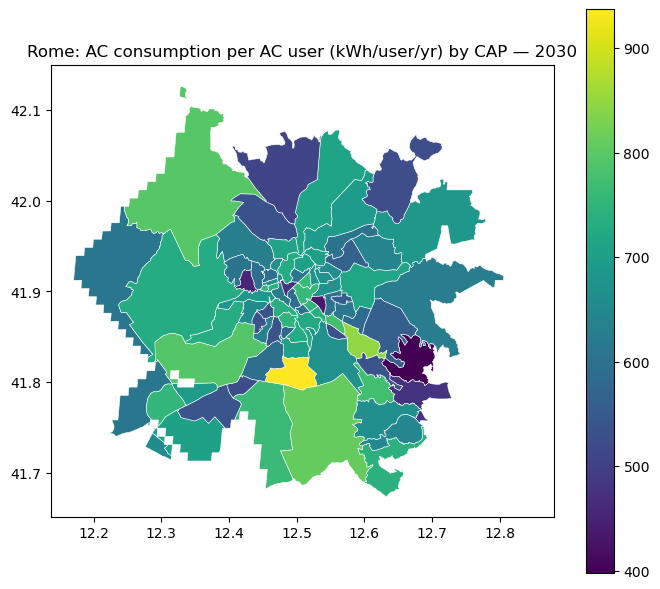

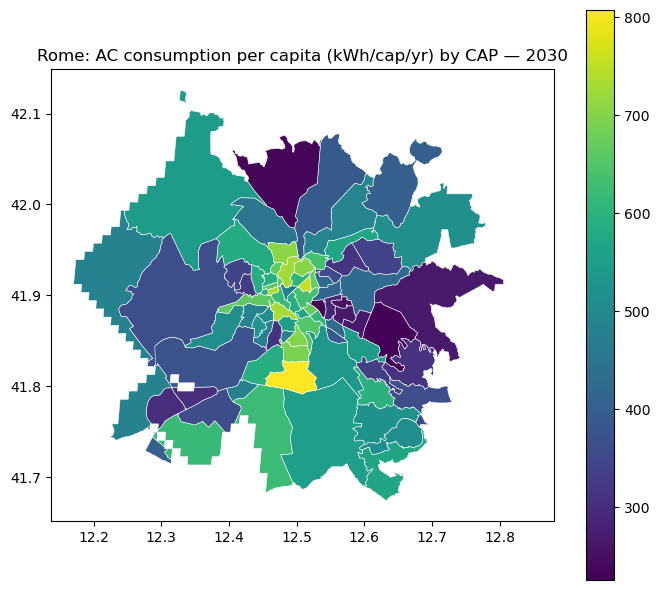


==== CAP-level results for year 2040 ====
City pop: 2,548,154
City AC users: 1,912,692  (AC share ≈ 0.751)
City total AC electricity: 695.960 GWh/yr
City per-AC-user mean (users-weighted): 363.863895 kWh/user/yr

Top 10 CAPs by kwh_pc_overall — kWh per capita (overall), 2040


,cap_id,ac_share_cap,kwh_per_user_cap,pop_cap,kwh_cap,kwh_pc_overall,year
0,106,1.000000,521.572449,11006.654093,5.740768e+06,521.572448,2040
1,69,1.000000,509.981598,26114.416008,1.331787e+07,509.981598,2040
2,99,1.000000,466.866211,24700.875166,1.153200e+07,466.866211,2040
3,108,1.000000,458.734253,17976.470407,8.246423e+06,458.734252,2040
4,90,0.744282,614.592102,15856.397256,7.253185e+06,457.429567,2040
5,61,1.000000,417.560913,36202.427533,1.511672e+07,417.560913,2040
6,107,1.000000,393.003296,9290.892429,3.651351e+06,393.003294,2040
7,49,0.936356,412.947327,17987.600166,6.955187e+06,386.665618,2040
8,105,1.000000,378.512695,24897.301921,9.423945e+06,378.512696,2040
9,101,1.000000,369.994720,25059.878205,9.272023e+06,369.994720,2040


Bottom 10 CAPs by kwh_pc_overall — kWh per capita (overall), 2040


,cap_id,ac_share_cap,kwh_per_user_cap,pop_cap,kwh_cap,kwh_pc_overall,year
0,93,0.494187,219.885864,27316.795516,2.968373e+06,108.664749,2040
1,103,0.470578,261.882721,11587.980538,1.428061e+06,123.236359,2040
2,48,0.450384,309.263733,37363.317353,5.204243e+06,139.287506,2040
3,86,0.464674,301.952545,34966.397290,4.906113e+06,140.309372,2040
4,53,0.422645,355.082672,103728.386679,1.556693e+07,150.073959,2040
5,41,0.408485,375.542084,17621.180532,2.703144e+06,153.403122,2040
6,85,0.585956,269.768158,48452.912045,7.659066e+06,158.072357,2040
7,92,0.535178,308.269745,27875.780769,4.598921e+06,164.979080,2040
8,45,0.705162,252.621445,11974.383601,2.133105e+06,178.139023,2040
9,87,0.457641,406.737823,20995.874449,3.908169e+06,186.139878,2040



Top 10 CAPs by kwh_cap — Total kWh, 2040


,cap_id,ac_share_cap,kwh_per_user_cap,pop_cap,kwh_cap,kwh_pc_overall,year
0,83,0.514410,430.879150,124767.276103,2.765449e+07,221.648575,2040
1,63,1.000000,335.044128,72016.976061,2.412886e+07,335.044128,2040
2,55,0.949958,311.701141,77077.603001,2.282290e+07,296.102875,2040
3,59,0.724316,443.394897,66337.303481,2.130476e+07,321.158020,2040
4,46,0.902811,280.495453,80341.231492,2.034517e+07,253.234467,2040
5,89,0.659802,540.308533,56324.068493,2.007933e+07,356.496490,2040
6,73,0.611596,399.343140,70384.133361,1.719039e+07,244.236664,2040
7,94,0.821181,404.076904,49626.653487,1.646714e+07,331.820434,2040
8,100,0.860672,394.689789,47104.179532,1.600122e+07,339.698547,2040
9,62,0.884360,401.578918,44494.561070,1.580181e+07,355.140198,2040


Bottom 10 CAPs by kwh_cap — Total kWh, 2040


,cap_id,ac_share_cap,kwh_per_user_cap,pop_cap,kwh_cap,kwh_pc_overall,year
0,42,0.813596,348.650513,220.220836,6.246799e+04,283.660671,2040
1,21,0.779407,346.332916,1151.152281,3.107354e+05,269.934235,2040
2,24,0.810850,416.735718,2401.749023,8.115750e+05,337.910004,2040
3,44,0.631916,376.873413,3973.220491,9.462319e+05,238.152375,2040
4,103,0.470578,261.882721,11587.980538,1.428061e+06,123.236359,2040
5,52,0.436072,477.279297,8590.451368,1.787914e+06,208.128021,2040
6,19,0.798823,419.374878,5608.371942,1.878840e+06,335.006257,2040
7,45,0.705162,252.621445,11974.383601,2.133105e+06,178.139023,2040
8,33,0.812389,415.847321,7703.112589,2.602342e+06,337.829895,2040
9,3,0.781029,357.374634,9452.473559,2.638375e+06,279.120087,2040


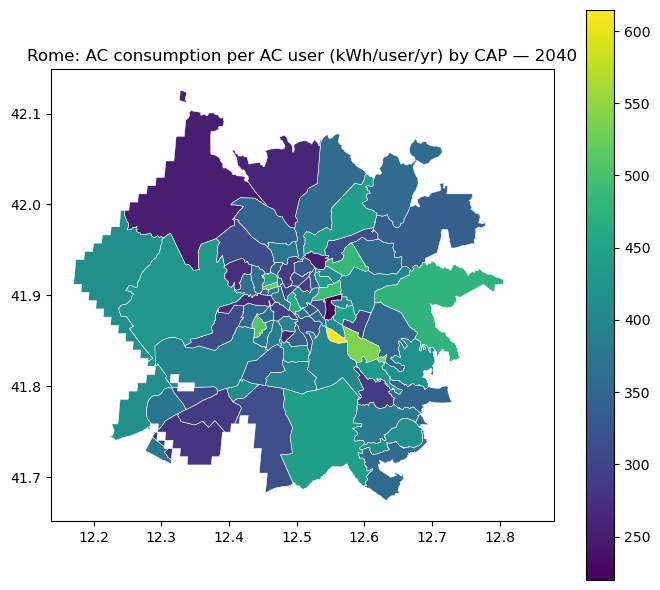

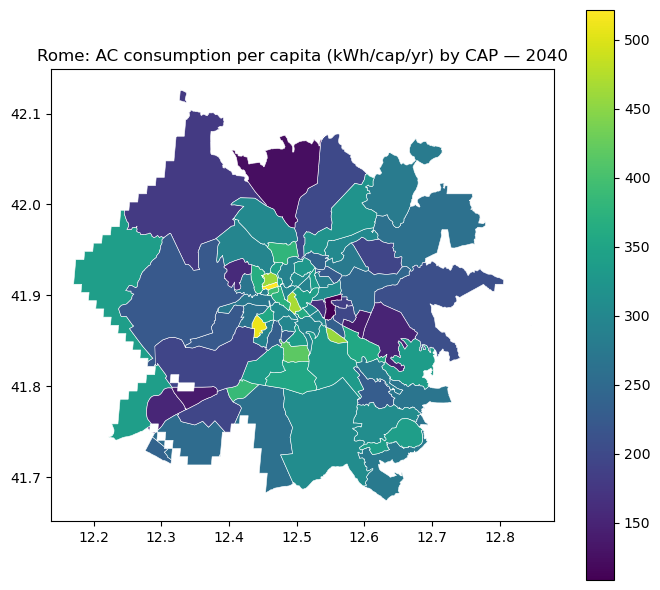


==== CAP-level results for year 2050 ====
City pop: 2,548,154
City AC users: 1,843,657  (AC share ≈ 0.724)
City total AC electricity: 1243.270 GWh/yr
City per-AC-user mean (users-weighted): 674.350078 kWh/user/yr

Top 10 CAPs by kwh_pc_overall — kWh per capita (overall), 2050


,cap_id,ac_share_cap,kwh_per_user_cap,pop_cap,kwh_cap,kwh_pc_overall,year
0,63,0.980000,855.880554,72016.976061,6.040517e+07,838.762940,2050
1,71,0.980000,848.096497,32908.613010,2.735149e+07,831.134582,2050
2,97,0.879726,902.932007,16740.808056,1.329777e+07,794.332580,2050
3,96,0.812105,977.762939,18005.116028,1.429689e+07,794.045775,2050
4,60,0.891723,874.658875,29343.199672,2.288633e+07,779.953432,2050
5,55,0.911318,855.504700,77077.603001,6.009256e+07,779.637086,2050
6,46,0.866090,846.857971,80341.231492,5.892667e+07,733.454895,2050
7,66,0.943934,742.874512,15601.997372,1.094050e+07,701.224242,2050
8,102,0.980000,698.603088,20959.327363,1.434941e+07,684.631041,2050
9,2,0.743228,903.583313,29339.252896,1.970331e+07,671.568358,2050


Bottom 10 CAPs by kwh_pc_overall — kWh per capita (overall), 2050


,cap_id,ac_share_cap,kwh_per_user_cap,pop_cap,kwh_cap,kwh_pc_overall,year
0,74,0.550156,396.975189,38743.295590,8.461466e+06,218.398208,2050
1,41,0.391869,600.007935,17621.180532,4.143177e+06,235.124801,2050
2,93,0.474086,513.868225,27316.795516,6.654857e+06,243.617767,2050
3,52,0.418335,604.300964,8590.451368,2.171666e+06,252.800003,2050
4,58,0.535197,485.050385,25145.130734,6.527614e+06,259.597534,2050
5,88,0.423475,635.295593,35544.090550,9.562501e+06,269.032105,2050
6,48,0.432065,640.731689,37363.317353,1.034357e+07,276.837677,2050
7,67,0.461699,604.209106,71779.269490,2.002372e+07,278.962464,2050
8,76,0.529315,546.545288,18611.006524,5.384067e+06,289.294769,2050
9,83,0.493487,592.560303,124767.276103,3.648451e+07,292.420532,2050



Top 10 CAPs by kwh_cap — Total kWh, 2050


,cap_id,ac_share_cap,kwh_per_user_cap,pop_cap,kwh_cap,kwh_pc_overall,year
0,63,0.980000,855.880554,72016.976061,6.040517e+07,838.762940,2050
1,55,0.911318,855.504700,77077.603001,6.009256e+07,779.637086,2050
2,46,0.866090,846.857971,80341.231492,5.892667e+07,733.454895,2050
3,59,0.694855,860.718323,66337.303481,3.967462e+07,598.074035,2050
4,83,0.493487,592.560303,124767.276103,3.648451e+07,292.420532,2050
5,47,0.652795,675.781189,80967.021722,3.571834e+07,441.146820,2050
6,53,0.405454,801.937134,103728.386679,3.372715e+07,325.148712,2050
7,50,0.802262,829.023438,49859.790069,3.316146e+07,665.094176,2050
8,73,0.586719,739.861450,70384.133361,3.055313e+07,434.091095,2050
9,82,0.952037,659.804260,45832.143144,2.878982e+07,628.157897,2050


Bottom 10 CAPs by kwh_cap — Total kWh, 2050


,cap_id,ac_share_cap,kwh_per_user_cap,pop_cap,kwh_cap,kwh_pc_overall,year
0,42,0.780503,487.517151,220.220836,8.379594e+04,380.508692,2050
1,21,0.747705,706.607727,1151.152281,6.081927e+05,528.333863,2050
2,44,0.606213,499.107178,3973.220491,1.202159e+06,302.565277,2050
3,24,0.777869,650.715820,2401.749023,1.215697e+06,506.171357,2050
4,52,0.418335,604.300964,8590.451368,2.171666e+06,252.800003,2050
5,19,0.766331,776.400696,5608.371942,3.336868e+06,594.979858,2050
6,33,0.779345,572.004395,7703.112589,3.433963e+06,445.789032,2050
7,3,0.749261,557.833618,9452.473559,3.950785e+06,417.963044,2050
8,106,0.980000,366.454010,11006.654093,3.952764e+06,359.124938,2050
9,41,0.391869,600.007935,17621.180532,4.143177e+06,235.124801,2050


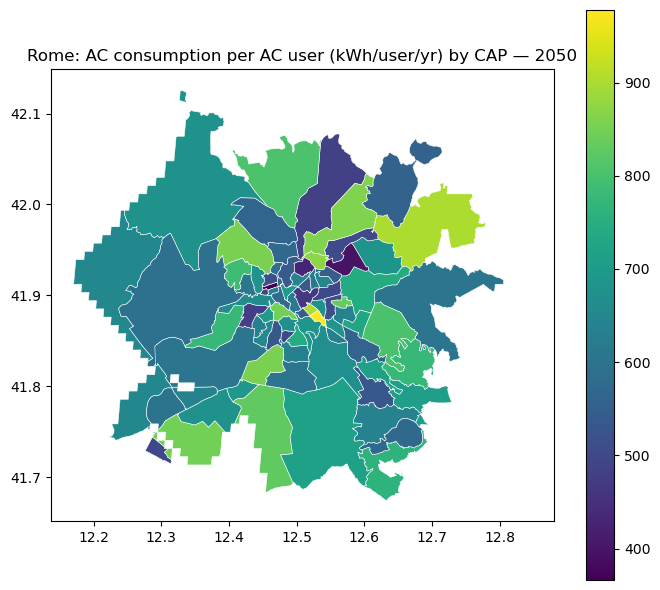

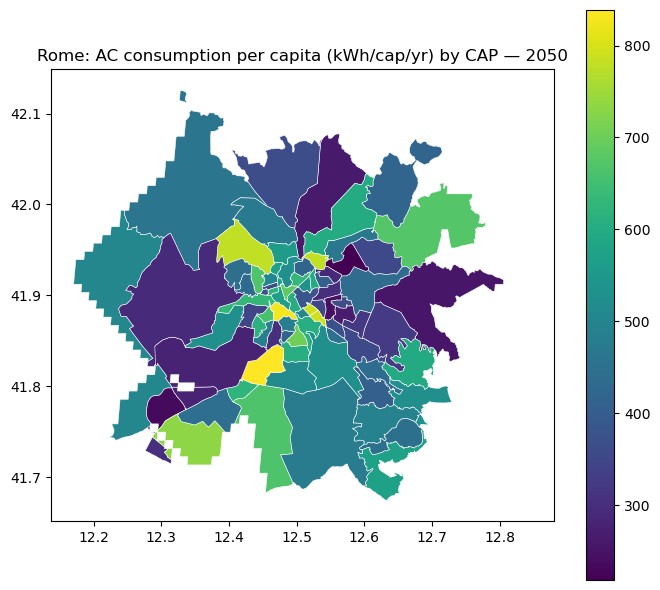

Saved: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome/rome_cap_ac_consumption_summary.csv
Saved: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome/rome_cap_ac_consumption_map.geojson


In [10]:
# CAP-level consumption tables and maps over multiple years
import numpy as np, pandas as pd, geopandas as gpd
import matplotlib.pyplot as plt
from pathlib import Path

years_maps = [2030, 2040, 2050]

pop_grid = pop_on_ref
cap_ids  = cap_on_ref

def show_rank(df, col, k=15, title=""):
    cols = ["cap_id","ac_share_cap","kwh_per_user_cap","pop_cap","kwh_cap","kwh_pc_overall","year"]
    top = df[cols].sort_values(col, ascending=False).head(k).reset_index(drop=True)
    bot = df[cols].sort_values(col, ascending=True).head(k).reset_index(drop=True)
    print(f"\nTop {k} CAPs by {col} — {title}"); display(top)
    print(f"Bottom {k} CAPs by {col} — {title}"); display(bot)

all_cap_tbl = []
all_cap_map = []

for year_map in years_maps:
    print(f"\n==== CAP-level results for year {year_map} ====")

    coverage_map = _cov_for_year(year_map)
    per_user_map = per_user_map_by_year[year_map]
    kwh_tot_map  = kwh_tot_map_by_year[year_map]
    cap_per_user = cap_per_user_by_year[year_map]

    # matched pixel universe: within city, with CAP, and finite for all needed layers
    CAP_PIX = (CITY_MASK &
               (cap_ids > 0) &
               np.isfinite(pop_grid) &
               np.isfinite(coverage_map) &
               np.isfinite(kwh_tot_map))

    # users and pop by CAP
    df_cap_base = pd.DataFrame({
        "cap_id": cap_ids[CAP_PIX].ravel().astype(int),
        "pop":    pop_grid[CAP_PIX].ravel().astype(float),
        "users": (coverage_map[CAP_PIX] * pop_grid[CAP_PIX]).ravel().astype(float),
    })
    cap_pop_users = (df_cap_base.groupby("cap_id", as_index=False)
                     .agg(pop_cap=("pop","sum"),
                          users_cap=("users","sum")))
    cap_pop_users["ac_share_cap"] = np.where(cap_pop_users["pop_cap"] > 0,
                                             cap_pop_users["users_cap"] / cap_pop_users["pop_cap"],
                                             np.nan)

    # energy totals by CAP (sum of pixel kWh)
    df_kwh = pd.DataFrame({
        "cap_id": cap_ids[CAP_PIX].ravel().astype(int),
        "kwh":    kwh_tot_map[CAP_PIX].ravel().astype(float),
    })
    cap_energy = (df_kwh.groupby("cap_id", as_index=False)
                  .agg(kwh_cap=("kwh","sum")))

    # merge and compute per-capita
    cap_tbl = (cap_pop_users
               .merge(cap_energy, on="cap_id", how="left")
               .merge(cap_per_user, on="cap_id", how="left"))
    cap_tbl["kwh_pc_overall"] = np.where(cap_tbl["pop_cap"] > 0,
                                         cap_tbl["kwh_cap"] / cap_tbl["pop_cap"], np.nan)
    cap_tbl["year"] = year_map
    all_cap_tbl.append(cap_tbl)

    # city checks on the same matched universe
    city_pop     = float(np.nansum(pop_grid[CAP_PIX]))
    city_users   = float(np.nansum((coverage_map * pop_grid)[CAP_PIX]))
    city_kwh_GWh = float(np.nansum(kwh_tot_map[CAP_PIX])) / 1e6
    per_user_mean_city = float(
        np.nansum(cap_tbl["kwh_per_user_cap"] * cap_tbl["users_cap"]) / max(city_users, 1e-12)
    )

    print(f"City pop: {city_pop:,.0f}")
    print(f"City AC users: {city_users:,.0f}  (AC share ≈ {city_users/city_pop:.3f})")
    print(f"City total AC electricity: {city_kwh_GWh:.3f} GWh/yr")
    print(f"City per-AC-user mean (users-weighted): {per_user_mean_city:.6f} kWh/user/yr")

    # ranks for this year
    show_rank(cap_tbl, "kwh_pc_overall", k=10, title=f"kWh per capita (overall), {year_map}")
    show_rank(cap_tbl, "kwh_cap",        k=10, title=f"Total kWh, {year_map}")

    # join to CAP polygons (cap_4326 loaded earlier)
    cap_map = cap_4326.merge(cap_tbl, on="cap_id", how="left")
    cap_map["year"] = year_map
    cap_map_4326 = cap_map.to_crs("EPSG:4326")
    all_cap_map.append(cap_map_4326)

    # maps for this year
    fig, ax = plt.subplots(1, 1, figsize=(7,6))
    cap_map_4326.plot(ax=ax, column="kwh_per_user_cap",
                      legend=True, linewidth=0.4, edgecolor="white")
    ax.set_title(f"{CITY}: AC consumption per AC user (kWh/user/yr) by CAP — {year_map}")
    plt.tight_layout(); plt.show()

    fig, ax = plt.subplots(1, 1, figsize=(7,6))
    cap_map_4326.plot(ax=ax, column="kwh_pc_overall",
                      legend=True, linewidth=0.4, edgecolor="white")
    ax.set_title(f"{CITY}: AC consumption per capita (kWh/cap/yr) by CAP — {year_map}")
    plt.tight_layout(); plt.show()

# save all years together 
OUT = Path(OUT); OUT.mkdir(parents=True, exist_ok=True)

cap_tbl_all = pd.concat(all_cap_tbl, ignore_index=True)
cap_tbl_all["kwh_GWh"] = cap_tbl_all["kwh_cap"] / 1e6
cap_tbl_csv = OUT / f"{SLUG}_cap_ac_consumption_summary.csv"
cap_tbl_all.to_csv(cap_tbl_csv, index=False)

cap_map_all = gpd.GeoDataFrame(pd.concat(all_cap_map, ignore_index=True), crs="EPSG:4326")
cap_geojson = OUT / f"{SLUG}_cap_ac_consumption_map.geojson"
(cap_map_all[["cap_id","geometry","year",
              "kwh_per_user_cap","ac_share_cap","kwh_pc_overall","kwh_cap"]]
        .to_file(cap_geojson, driver="GeoJSON"))

print("Saved:", cap_tbl_csv)
print("Saved:", cap_geojson)

And as we said, we downscaled the **electricity consumption to the the CAPs level** 

**Aggregation at the Municipio level**


==== Municipio-level results for year 2030 ====
City diagnostics by universe:
[ALL FUA] per-user=663.438527  AC-share=0.735  total=1241.712 GWh  pop=2,548,154  users=1,871,630
[Municipi-only (muni_on_ref>0)] per-user=662.387568  AC-share=0.732  total=1167.466 GWh  pop=2,406,440  users=1,762,512
[Outside Municipi (muni_id==0)] per-user=680.416204  AC-share=0.770  total=74.245 GWh  pop=141,714  users=109,118

Check: in + out should equal all
users: 1871630.21875 vs 1871630.25
GWh:   1241.7118320000002 vs 1241.711616

From groupby (includes muni_id=0):
Users-weighted per-user mean (city): 663.4386036204235
City total GWh: 1241.7117440342688

Top 10 Municipi by kwh_pc_overall — kWh per capita (overall), 2030


,muni_id,ac_share_muni,kwh_per_user_muni,pop_muni,kwh_muni,kwh_pc_overall,year
0,2,0.967965,697.892390,161260.130027,1.089369e+08,675.535405,2030
1,9,0.870092,717.465447,218657.720215,1.364994e+08,624.260670,2030
2,1,0.964461,643.119079,179186.877781,1.111431e+08,620.263450,2030
3,8,0.849112,692.151276,113650.658718,6.679410e+07,587.714124,2030
4,15,0.854346,617.161419,99254.233600,5.233374e+07,527.269587,2030
5,3,0.760811,676.157358,148399.737608,7.634097e+07,514.427924,2030
6,12,0.785124,623.720759,131663.470656,6.447536e+07,489.698145,2030
7,7,0.711969,687.134767,248261.719912,1.214542e+08,489.218502,2030
8,14,0.740247,628.696872,158462.193480,7.374683e+07,465.390706,2030
9,13,0.671236,667.705275,130701.853861,5.857897e+07,448.187787,2030


Bottom 10 Municipi by kwh_pc_overall — kWh per capita (overall), 2030


,muni_id,ac_share_muni,kwh_per_user_muni,pop_muni,kwh_muni,kwh_pc_overall,year
0,6,0.425590,575.893587,129944.772669,3.184879e+07,245.094810,2030
1,5,0.513378,624.521522,175712.888959,5.633632e+07,320.615774,2030
2,4,0.590926,643.836940,170679.730356,6.493679e+07,380.459893,2030
3,11,0.559448,697.292269,119803.339214,4.673514e+07,390.098788,2030
4,10,0.682021,646.159939,220800.462973,9.730563e+07,440.694859,2030
5,13,0.671236,667.705275,130701.853861,5.857897e+07,448.187787,2030
6,14,0.740247,628.696872,158462.193480,7.374683e+07,465.390706,2030
7,7,0.711969,687.134767,248261.719912,1.214542e+08,489.218502,2030
8,12,0.785124,623.720759,131663.470656,6.447536e+07,489.698145,2030
9,3,0.760811,676.157358,148399.737608,7.634097e+07,514.427924,2030



Top 10 Municipi by kwh_muni — Total kWh, 2030


,muni_id,ac_share_muni,kwh_per_user_muni,pop_muni,kwh_muni,kwh_pc_overall,year
0,9,0.870092,717.465447,218657.720215,1.364994e+08,624.260670,2030
1,7,0.711969,687.134767,248261.719912,1.214542e+08,489.218502,2030
2,1,0.964461,643.119079,179186.877781,1.111431e+08,620.263450,2030
3,2,0.967965,697.892390,161260.130027,1.089369e+08,675.535405,2030
4,10,0.682021,646.159939,220800.462973,9.730563e+07,440.694859,2030
5,3,0.760811,676.157358,148399.737608,7.634097e+07,514.427924,2030
6,14,0.740247,628.696872,158462.193480,7.374683e+07,465.390706,2030
7,8,0.849112,692.151276,113650.658718,6.679410e+07,587.714124,2030
8,4,0.590926,643.836940,170679.730356,6.493679e+07,380.459893,2030
9,12,0.785124,623.720759,131663.470656,6.447536e+07,489.698145,2030


Bottom 10 Municipi by kwh_muni — Total kWh, 2030


,muni_id,ac_share_muni,kwh_per_user_muni,pop_muni,kwh_muni,kwh_pc_overall,year
0,6,0.425590,575.893587,129944.772669,3.184879e+07,245.094810,2030
1,11,0.559448,697.292269,119803.339214,4.673514e+07,390.098788,2030
2,15,0.854346,617.161419,99254.233600,5.233374e+07,527.269587,2030
3,5,0.513378,624.521522,175712.888959,5.633632e+07,320.615774,2030
4,13,0.671236,667.705275,130701.853861,5.857897e+07,448.187787,2030
5,12,0.785124,623.720759,131663.470656,6.447536e+07,489.698145,2030
6,4,0.590926,643.836940,170679.730356,6.493679e+07,380.459893,2030
7,8,0.849112,692.151276,113650.658718,6.679410e+07,587.714124,2030
8,14,0.740247,628.696872,158462.193480,7.374683e+07,465.390706,2030
9,3,0.760811,676.157358,148399.737608,7.634097e+07,514.427924,2030


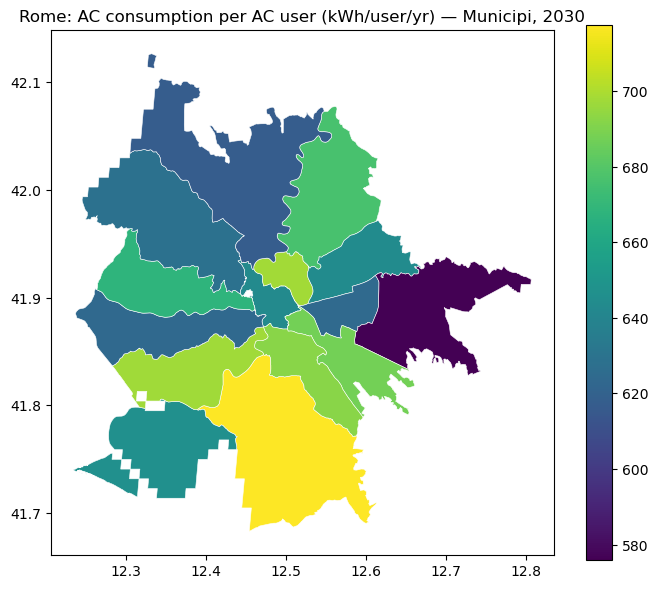

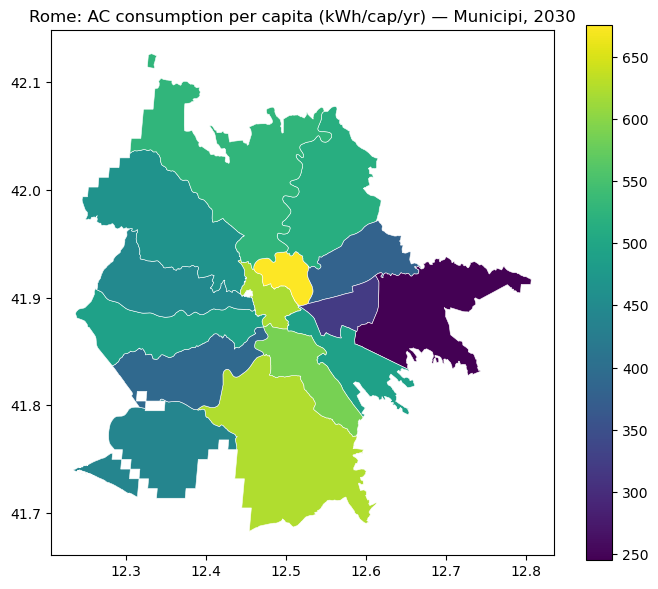


==== Municipio-level results for year 2040 ====
City diagnostics by universe:
[ALL FUA] per-user=363.863919  AC-share=0.751  total=695.960 GWh  pop=2,548,154  users=1,912,692
[Municipi-only (muni_on_ref>0)] per-user=364.849962  AC-share=0.748  total=656.966 GWh  pop=2,406,440  users=1,800,648
[Outside Municipi (muni_id==0)] per-user=348.017573  AC-share=0.791  total=38.993 GWh  pop=141,714  users=112,044

Check: in + out should equal all
users: 1912692.375 vs 1912692.375
GWh:   695.959768 vs 695.959744

From groupby (includes muni_id=0):
Users-weighted per-user mean (city): 363.86389082995976
City total GWh: 695.9596989377932

Top 10 Municipi by kwh_pc_overall — kWh per capita (overall), 2040


,muni_id,ac_share_muni,kwh_per_user_muni,pop_muni,kwh_muni,kwh_pc_overall,year
0,1,0.973240,383.976931,179186.877781,6.696246e+07,373.701795,2040
1,8,0.870733,378.458323,113650.658718,3.745199e+07,329.536048,2040
2,9,0.886354,363.513680,218657.720215,7.045188e+07,322.201642,2040
3,12,0.802851,395.226102,131663.470656,4.177781e+07,317.307492,2040
4,2,0.976027,324.298245,161260.130027,5.104265e+07,316.523694,2040
5,7,0.731022,427.071473,248261.719912,7.750699e+07,312.198708,2040
6,15,0.871872,337.679177,99254.233600,2.922172e+07,294.412864,2040
7,3,0.781159,359.311554,148399.737608,4.165274e+07,280.679361,2040
8,4,0.606723,424.493940,170679.730356,4.395863e+07,257.550403,2040
9,14,0.757036,326.451140,158462.193480,3.916160e+07,247.135297,2040


Bottom 10 Municipi by kwh_pc_overall — kWh per capita (overall), 2040


,muni_id,ac_share_muni,kwh_per_user_muni,pop_muni,kwh_muni,kwh_pc_overall,year
0,6,0.437005,357.303021,129944.772669,2.028998e+07,156.143112,2040
1,5,0.527147,367.067507,175712.888959,3.400019e+07,193.498538,2040
2,10,0.700313,291.636062,220800.462973,4.509552e+07,204.236541,2040
3,11,0.574342,389.960723,119803.339214,2.683247e+07,223.970991,2040
4,13,0.689168,350.369253,130701.853861,3.155970e+07,241.463285,2040
5,14,0.757036,326.451140,158462.193480,3.916160e+07,247.135297,2040
6,4,0.606723,424.493940,170679.730356,4.395863e+07,257.550403,2040
7,3,0.781159,359.311554,148399.737608,4.165274e+07,280.679361,2040
8,15,0.871872,337.679177,99254.233600,2.922172e+07,294.412864,2040
9,7,0.731022,427.071473,248261.719912,7.750699e+07,312.198708,2040



Top 10 Municipi by kwh_muni — Total kWh, 2040


,muni_id,ac_share_muni,kwh_per_user_muni,pop_muni,kwh_muni,kwh_pc_overall,year
0,7,0.731022,427.071473,248261.719912,7.750699e+07,312.198708,2040
1,9,0.886354,363.513680,218657.720215,7.045188e+07,322.201642,2040
2,1,0.973240,383.976931,179186.877781,6.696246e+07,373.701795,2040
3,2,0.976027,324.298245,161260.130027,5.104265e+07,316.523694,2040
4,10,0.700313,291.636062,220800.462973,4.509552e+07,204.236541,2040
5,4,0.606723,424.493940,170679.730356,4.395863e+07,257.550403,2040
6,12,0.802851,395.226102,131663.470656,4.177781e+07,317.307492,2040
7,3,0.781159,359.311554,148399.737608,4.165274e+07,280.679361,2040
8,14,0.757036,326.451140,158462.193480,3.916160e+07,247.135297,2040
9,8,0.870733,378.458323,113650.658718,3.745199e+07,329.536048,2040


Bottom 10 Municipi by kwh_muni — Total kWh, 2040


,muni_id,ac_share_muni,kwh_per_user_muni,pop_muni,kwh_muni,kwh_pc_overall,year
0,6,0.437005,357.303021,129944.772669,2.028998e+07,156.143112,2040
1,11,0.574342,389.960723,119803.339214,2.683247e+07,223.970991,2040
2,15,0.871872,337.679177,99254.233600,2.922172e+07,294.412864,2040
3,13,0.689168,350.369253,130701.853861,3.155970e+07,241.463285,2040
4,5,0.527147,367.067507,175712.888959,3.400019e+07,193.498538,2040
5,8,0.870733,378.458323,113650.658718,3.745199e+07,329.536048,2040
6,14,0.757036,326.451140,158462.193480,3.916160e+07,247.135297,2040
7,3,0.781159,359.311554,148399.737608,4.165274e+07,280.679361,2040
8,12,0.802851,395.226102,131663.470656,4.177781e+07,317.307492,2040
9,4,0.606723,424.493940,170679.730356,4.395863e+07,257.550403,2040


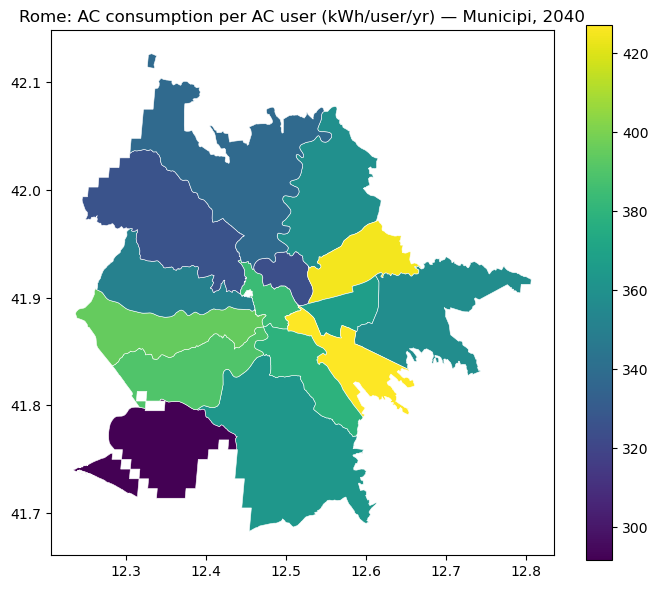

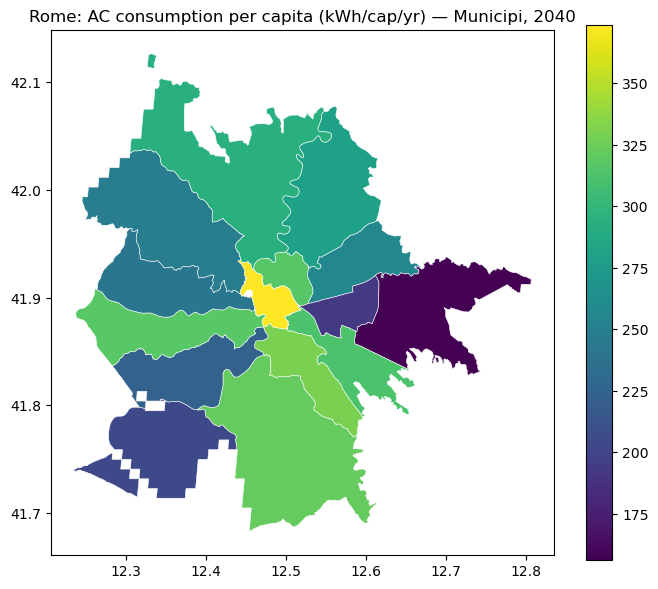


==== Municipio-level results for year 2050 ====
City diagnostics by universe:
[ALL FUA] per-user=674.350049  AC-share=0.724  total=1243.270 GWh  pop=2,548,154  users=1,843,657
[Municipi-only (muni_on_ref>0)] per-user=674.567529  AC-share=0.721  total=1171.164 GWh  pop=2,406,440  users=1,736,170
[Outside Municipi (muni_id==0)] per-user=670.838021  AC-share=0.758  total=72.106 GWh  pop=141,714  users=107,487

Check: in + out should equal all
users: 1843657.234375 vs 1843657.125
GWh:   1243.270432 vs 1243.270272

From groupby (includes muni_id=0):
Users-weighted per-user mean (city): 674.3500730789192
City total GWh: 1243.2703282675677

Top 10 Municipi by kwh_pc_overall — kWh per capita (overall), 2050


,muni_id,ac_share_muni,kwh_per_user_muni,pop_muni,kwh_muni,kwh_pc_overall,year
0,9,0.857087,766.747502,218657.720215,1.436952e+08,657.169595,2050
1,1,0.950047,620.229442,179186.877781,1.055853e+08,589.246867,2050
2,15,0.841577,666.716307,99254.233600,5.569089e+07,561.093370,2050
3,14,0.729183,756.887687,158462.193480,8.745681e+07,551.909605,2050
4,3,0.749440,734.926393,148399.737608,8.173609e+07,550.783237,2050
5,8,0.836422,638.899347,113650.658718,6.073368e+07,534.389192,2050
6,2,0.953498,546.295256,161260.130027,8.399902e+07,520.891411,2050
7,12,0.773390,659.050413,131663.470656,6.710924e+07,509.702787,2050
8,10,0.671828,746.253813,220800.462973,1.106992e+08,501.354154,2050
9,7,0.701328,689.272328,248261.719912,1.200112e+08,483.405855,2050


Bottom 10 Municipi by kwh_pc_overall — kWh per capita (overall), 2050


,muni_id,ac_share_muni,kwh_per_user_muni,pop_muni,kwh_muni,kwh_pc_overall,year
0,6,0.419230,772.452601,129944.772669,4.208067e+07,323.835036,2050
1,4,0.582094,566.370767,170679.730356,5.626987e+07,329.681006,2050
2,11,0.551087,615.312513,119803.339214,4.062417e+07,339.090484,2050
3,5,0.505705,686.930323,175712.888959,6.103991e+07,347.384373,2050
4,13,0.661204,629.859424,130701.853861,5.443280e+07,416.465432,2050
5,7,0.701328,689.272328,248261.719912,1.200112e+08,483.405855,2050
6,10,0.671828,746.253813,220800.462973,1.106992e+08,501.354154,2050
7,12,0.773390,659.050413,131663.470656,6.710924e+07,509.702787,2050
8,2,0.953498,546.295256,161260.130027,8.399902e+07,520.891411,2050
9,8,0.836422,638.899347,113650.658718,6.073368e+07,534.389192,2050



Top 10 Municipi by kwh_muni — Total kWh, 2050


,muni_id,ac_share_muni,kwh_per_user_muni,pop_muni,kwh_muni,kwh_pc_overall,year
0,9,0.857087,766.747502,218657.720215,1.436952e+08,657.169595,2050
1,7,0.701328,689.272328,248261.719912,1.200112e+08,483.405855,2050
2,10,0.671828,746.253813,220800.462973,1.106992e+08,501.354154,2050
3,1,0.950047,620.229442,179186.877781,1.055853e+08,589.246867,2050
4,14,0.729183,756.887687,158462.193480,8.745681e+07,551.909605,2050
5,2,0.953498,546.295256,161260.130027,8.399902e+07,520.891411,2050
6,3,0.749440,734.926393,148399.737608,8.173609e+07,550.783237,2050
7,12,0.773390,659.050413,131663.470656,6.710924e+07,509.702787,2050
8,5,0.505705,686.930323,175712.888959,6.103991e+07,347.384373,2050
9,8,0.836422,638.899347,113650.658718,6.073368e+07,534.389192,2050


Bottom 10 Municipi by kwh_muni — Total kWh, 2050


,muni_id,ac_share_muni,kwh_per_user_muni,pop_muni,kwh_muni,kwh_pc_overall,year
0,11,0.551087,615.312513,119803.339214,4.062417e+07,339.090484,2050
1,6,0.419230,772.452601,129944.772669,4.208067e+07,323.835036,2050
2,13,0.661204,629.859424,130701.853861,5.443280e+07,416.465432,2050
3,15,0.841577,666.716307,99254.233600,5.569089e+07,561.093370,2050
4,4,0.582094,566.370767,170679.730356,5.626987e+07,329.681006,2050
5,8,0.836422,638.899347,113650.658718,6.073368e+07,534.389192,2050
6,5,0.505705,686.930323,175712.888959,6.103991e+07,347.384373,2050
7,12,0.773390,659.050413,131663.470656,6.710924e+07,509.702787,2050
8,3,0.749440,734.926393,148399.737608,8.173609e+07,550.783237,2050
9,2,0.953498,546.295256,161260.130027,8.399902e+07,520.891411,2050


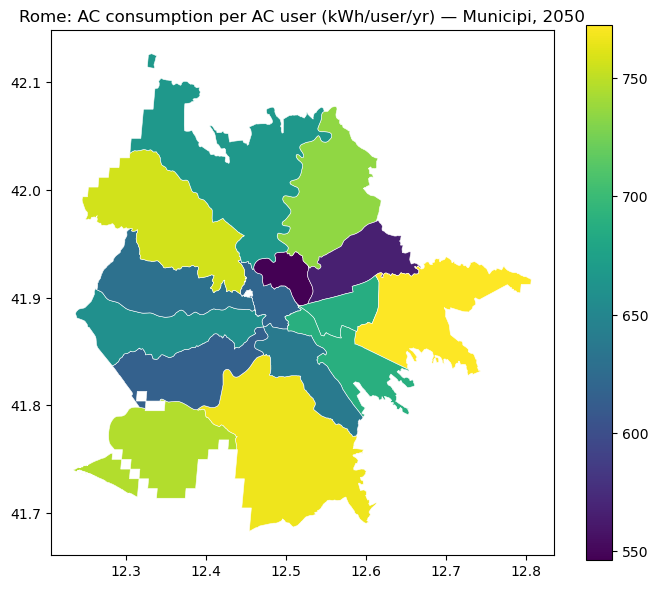

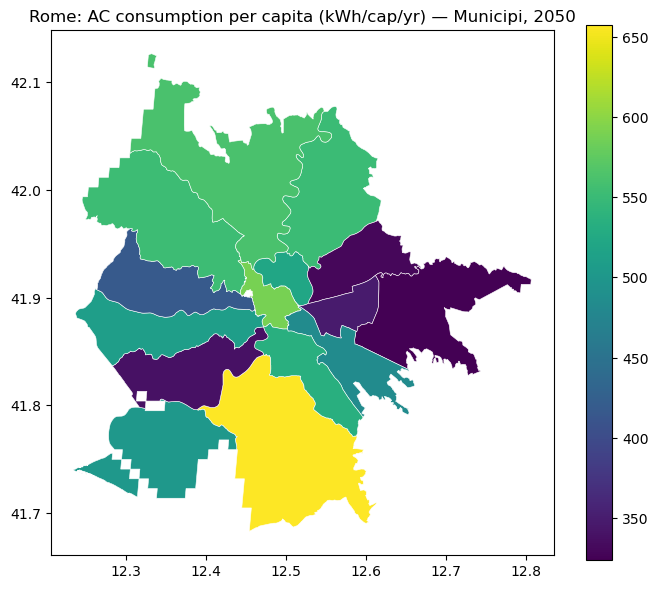

Saved: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome/rome_muni_ac_consumption_summary.csv
Saved: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome/rome_muni_ac_consumption_map.geojson


In [11]:
# Municipio-level AC electricity: per-user, per-capita, totals over multiple years
import numpy as np, pandas as pd, geopandas as gpd
import matplotlib.pyplot as plt
from pathlib import Path

years_maps = [2030, 2040, 2050]

assert 'muni_on_ref' in globals(), "muni_on_ref raster missing."
assert 'muni' in globals() and isinstance(muni, gpd.GeoDataFrame), "muni GeoDataFrame missing."

pop_grid = pop_on_ref

def _wavg(x, w):
    x = np.asarray(x, float)
    w = np.asarray(w, float)
    s = np.nansum(w)
    return float(np.nansum(x * w) / s) if s > 0 else np.nan

def show_rank_muni(df_in, col, k=10, title=""):
    cols = ["muni_id","ac_share_muni","kwh_per_user_muni",
            "pop_muni","kwh_muni","kwh_pc_overall","year"]
    top = df_in[cols].sort_values(col, ascending=False).head(k).reset_index(drop=True)
    bot = df_in[cols].sort_values(col, ascending=True).head(k).reset_index(drop=True)
    print(f"\nTop {k} Municipi by {col} — {title}"); display(top)
    print(f"Bottom {k} Municipi by {col} — {title}"); display(bot)

all_muni_tbl = []
all_muni_map = []

for year_map in years_maps:
    print(f"\n==== Municipio-level results for year {year_map} ====")

    coverage_map = _cov_for_year(year_map)
    per_user_map = per_user_map_by_year[year_map]
    kwh_tot_map  = kwh_tot_map_by_year[year_map]

    def city_diag(mask, label):
        users = float(np.nansum((coverage_map * pop_grid)[mask]))
        per_user = float(np.nansum((per_user_map * coverage_map * pop_grid)[mask]) / max(users, 1e-12))
        kwh = float(np.nansum(kwh_tot_map[mask])) / 1e6
        pop = float(np.nansum(pop_grid[mask]))
        print(f"[{label}] per-user={per_user:.6f}  AC-share={users/pop:.3f}  "
              f"total={kwh:.3f} GWh  pop={pop:,.0f}  users={users:,.0f}")
        return per_user, users, kwh

    # universes (keep id==0 as "outside" bucket)
    mask_all = CITY_MASK
    mask_in  = CITY_MASK & (muni_on_ref > 0)
    mask_out = CITY_MASK & (muni_on_ref == 0)

    print("City diagnostics by universe:")
    pu_all, u_all, k_all = city_diag(mask_all, "ALL FUA")
    pu_in,  u_in,  k_in  = city_diag(mask_in,  "Municipi-only (muni_on_ref>0)")
    pu_out, u_out, k_out = city_diag(mask_out, "Outside Municipi (muni_id==0)")

    print("\nCheck: in + out should equal all")
    print("users:", u_in + u_out, "vs", u_all)
    print("GWh:  ", k_in + k_out, "vs", k_all)

    # Build pixel to Municipio table over the full city mask (includes muni_id==0) 
    valid_all = (CITY_MASK &
                 np.isfinite(per_user_map) &
                 np.isfinite(kwh_tot_map) &
                 np.isfinite(pop_grid) &
                 np.isfinite(coverage_map))

    df = pd.DataFrame({
        "muni_id":  muni_on_ref[valid_all].ravel().astype(int),           # includes 0
        "pop":      pop_grid[valid_all].ravel().astype(float),
        "users":   (coverage_map[valid_all] * pop_grid[valid_all]).ravel().astype(float),
        "kwh":      kwh_tot_map[valid_all].ravel().astype(float),
        "per_user": per_user_map[valid_all].ravel().astype(float),
    })

    # users-weighted per-user by municipio
    per_user_by_muni = (df.groupby("muni_id")
                          .apply(lambda g: _wavg(g["per_user"], g["users"]))
                          .reset_index(name="kwh_per_user_muni"))

    # totals by municipio
    muni_tbl_all = (df.groupby("muni_id", as_index=False)
                      .agg(pop_muni=("pop","sum"),
                           users_muni=("users","sum"),
                           kwh_muni=("kwh","sum"))
                      .merge(per_user_by_muni, on="muni_id", how="left"))

    # rates
    muni_tbl_all["ac_share_muni"]  = np.where(muni_tbl_all["pop_muni"] > 0,
                                              muni_tbl_all["users_muni"] / muni_tbl_all["pop_muni"], np.nan)
    muni_tbl_all["kwh_pc_overall"] = np.where(muni_tbl_all["pop_muni"] > 0,
                                              muni_tbl_all["kwh_muni"]  / muni_tbl_all["pop_muni"], np.nan)
    muni_tbl_all["year"] = year_map
    all_muni_tbl.append(muni_tbl_all)

    # city diagnostics from grouped table
    users_sum = float(muni_tbl_all["users_muni"].sum())
    per_user_from_groups = float(
        np.nansum(muni_tbl_all["kwh_per_user_muni"] * muni_tbl_all["users_muni"])
        / max(users_sum, 1e-12)
    )
    kwh_sum = float(muni_tbl_all["kwh_muni"].sum()) / 1e6
    print("\nFrom groupby (includes muni_id=0):")
    print("Users-weighted per-user mean (city):", per_user_from_groups)
    print("City total GWh:", kwh_sum)

    # tables and maps for Municipi only (exclude id==0 for reporting) 
    muni_only = muni_tbl_all[muni_tbl_all["muni_id"] > 0].copy()

    show_rank_muni(muni_only, "kwh_pc_overall", k=10,
                   title=f"kWh per capita (overall), {year_map}")
    show_rank_muni(muni_only, "kwh_muni",       k=10,
                   title=f"Total kWh, {year_map}")

    # map join 
    muni_map = (muni[["muni_id","muni_name","geometry"]] if "muni_name" in muni.columns
                else muni[["muni_id","geometry"]]).merge(muni_only, on="muni_id", how="left")
    muni_map["year"] = year_map
    muni_map_4326 = muni_map.to_crs("EPSG:4326")
    all_muni_map.append(muni_map_4326)

    fig, ax = plt.subplots(1,1, figsize=(7,6))
    muni_map_4326.plot(ax=ax, column="kwh_per_user_muni",
                       legend=True, linewidth=0.4, edgecolor="white")
    ax.set_title(f"{CITY}: AC consumption per AC user (kWh/user/yr) — Municipi, {year_map}")
    plt.tight_layout(); plt.show()

    fig, ax = plt.subplots(1,1, figsize=(7,6))
    muni_map_4326.plot(ax=ax, column="kwh_pc_overall",
                       legend=True, linewidth=0.4, edgecolor="white")
    ax.set_title(f"{CITY}: AC consumption per capita (kWh/cap/yr) — Municipi, {year_map}")
    plt.tight_layout(); plt.show()

# saving all years together 
OUT = Path(OUT); OUT.mkdir(parents=True, exist_ok=True)

muni_tbl_all_years = pd.concat(all_muni_tbl, ignore_index=True)
muni_csv = OUT / f"{SLUG}_muni_ac_consumption_summary.csv"
(muni_tbl_all_years
    .assign(kwh_GWh=lambda d: d["kwh_muni"]/1e6)
    .to_csv(muni_csv, index=False))

muni_map_all = gpd.GeoDataFrame(pd.concat(all_muni_map, ignore_index=True), crs="EPSG:4326")
muni_geo = OUT / f"{SLUG}_muni_ac_consumption_map.geojson"
(muni_map_all[["muni_id","geometry","year",
               "kwh_per_user_muni","ac_share_muni","kwh_pc_overall","kwh_muni"]]
    .to_file(muni_geo, driver="GeoJSON"))

print("Saved:", muni_csv)
print("Saved:", muni_geo)

<blockquote style="border-left:4px solid #ccc; padding-left:1em;">
Why do the maps per AC user and per capita look different? Because the denominator is not the same. Per-AC_user varies because we draw CAP-level kWh/user around the city mean and scale it to match the city target. The map reflects only usage among households that have AC while the per-capita divides this same energy across everyone in the CAP. It equals AC share*per-AC-user. So places with low ownership look much lower per-capita even if users there consume a lot. Conversely, places with high ownership look high even if users don't consume unusually much. Finally, about the Municipi vs CAP, municipio values are population-weighted aggregates of the CAPs inside them. Rankings of totals differ because total kWh = per-capita * population. 
</blockquote>